## Подготовка среды

In [1]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [3]:
BASE_DIR = Path(".")
ARTIFACTS_DIR = BASE_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
DATA_PATH = BASE_DIR / "S12-hw-dataset.csv"
RUNS_PATH = ARTIFACTS_DIR / "runs.csv"

ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("Exists:", DATA_PATH.exists())

DATA_PATH: S12-hw-dataset.csv
Exists: True


## Загрузка и подготовка данных

In [4]:
df = pd.read_csv(DATA_PATH)
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [5]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


## Проверка данных и визуализация

In [6]:
print("Размер датасета:", df.shape)
print("Диапазон дат:", df["date"].min(), "->", df["date"].max())
print("\nПропуски по колонкам:")
print(df.isna().sum())

Размер датасета: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 -> 2025-06-29 23:00:00

Пропуски по колонкам:
date      0
target    0
dtype: int64


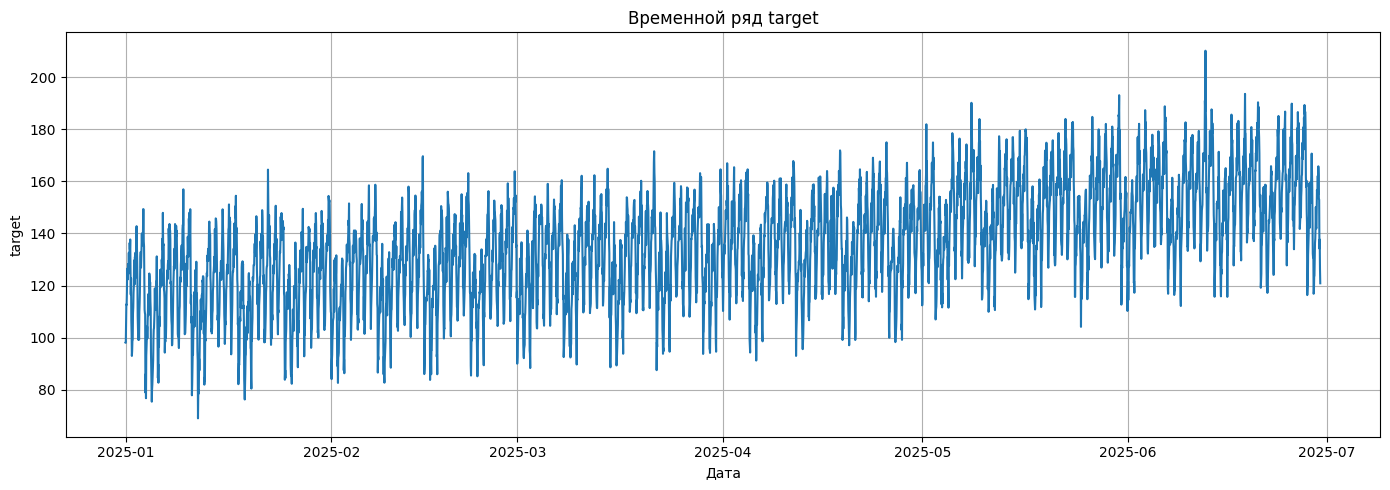

In [7]:
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["target"])
plt.title("Временной ряд target")
plt.xlabel("Дата")
plt.ylabel("target")
plt.grid(True)
plt.tight_layout()
plt.show()

## Корректный temporal split

In [8]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train:", train_df["date"].min(), "->", train_df["date"].max(), "|", len(train_df))
print("Validation:", val_df["date"].min(), "->", val_df["date"].max(), "|", len(val_df))
print("Test:", test_df["date"].min(), "->", test_df["date"].max(), "|", len(test_df))

Train: 2025-01-01 00:00:00 -> 2025-05-06 23:00:00 | 3024
Validation: 2025-05-07 00:00:00 -> 2025-06-02 23:00:00 | 648
Test: 2025-06-03 00:00:00 -> 2025-06-29 23:00:00 | 648


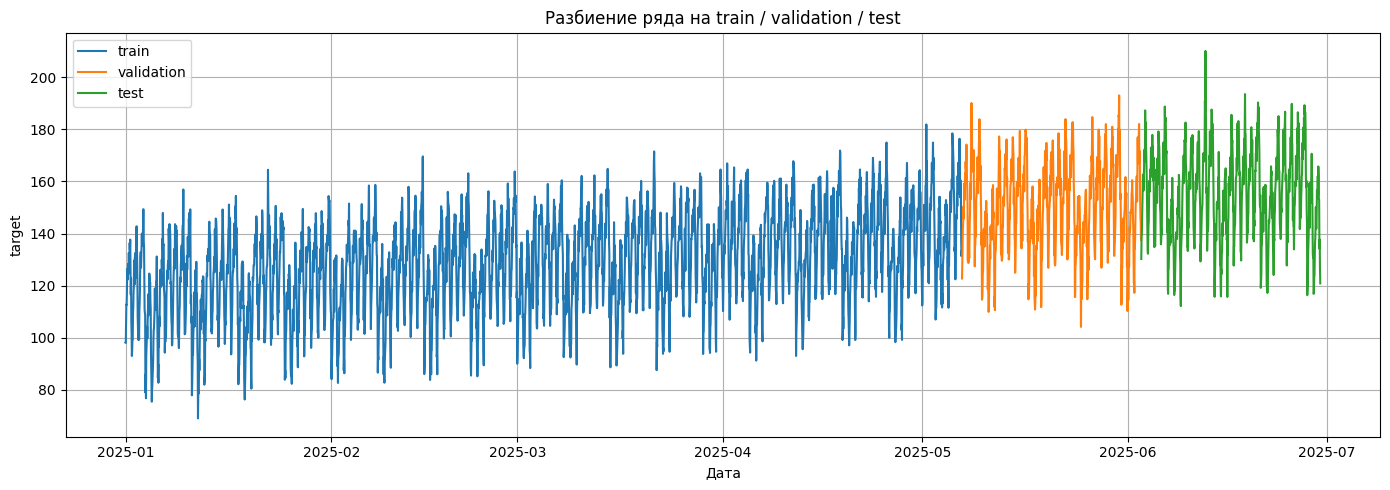

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(train_df["date"], train_df["target"], label="train")
plt.plot(val_df["date"], val_df["target"], label="validation")
plt.plot(test_df["date"], test_df["target"], label="test")
plt.title("Разбиение ряда на train / validation / test")
plt.xlabel("Дата")
plt.ylabel("target")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "series_split.png", dpi=150)
plt.show()

Для временных рядов `random split` использовать нельзя, потому что он перемешивает прошлые и будущие наблюдения между `train`, `validation` и `test`. В результате модель может косвенно получать информацию из будущего, а оценка качества становится слишком оптимистичной. В задаче прогнозирования модель должна обучаться только на прошлом и проверяться на будущих отрезках ряда, поэтому здесь используется только хронологический `temporal split`.

In [10]:
print("Random split для временного ряда некорректен, потому что смешивает прошлое и будущее и приводит к утечке информации.")

Random split для временного ряда некорректен, потому что смешивает прошлое и будущее и приводит к утечке информации.


## Построение признаков для baseline-моделей

In [11]:
feat_df = df.copy()

feat_df["lag_1"] = feat_df["target"].shift(1)
feat_df["lag_7"] = feat_df["target"].shift(7)
feat_df["lag_14"] = feat_df["target"].shift(14)

feat_df["rolling_mean_7"] = feat_df["target"].shift(1).rolling(7).mean()
feat_df["rolling_std_7"] = feat_df["target"].shift(1).rolling(7).std()

feat_df["day_of_week"] = feat_df["date"].dt.dayofweek

## Подготовка выборок и метрик

In [12]:
feature_cols = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "day_of_week"
]

model_df = feat_df[["date", "target"] + feature_cols].copy()

model_df = model_df.replace([np.inf, -np.inf], np.nan)

print("Пропуски до очистки:")
print(model_df[["target"] + feature_cols].isna().sum())

Пропуски до очистки:
target             0
lag_1              1
lag_7              7
lag_14            14
rolling_mean_7     7
rolling_std_7      7
day_of_week        0
dtype: int64


In [13]:
model_df = model_df.dropna(subset=["target"] + feature_cols).reset_index(drop=True)

print("Размер после очистки:", model_df.shape)
print("\nПропуски после очистки:")
print(model_df[["target"] + feature_cols].isna().sum())

Размер после очистки: (4306, 8)

Пропуски после очистки:
target            0
lag_1             0
lag_7             0
lag_14            0
rolling_mean_7    0
rolling_std_7     0
day_of_week       0
dtype: int64


In [14]:
n_model = len(model_df)
train_end_model = int(n_model * 0.70)
val_end_model = int(n_model * 0.85)

train_model = model_df.iloc[:train_end_model].copy()
val_model = model_df.iloc[train_end_model:val_end_model].copy()
test_model = model_df.iloc[val_end_model:].copy()

print("Train:", train_model["date"].min(), "->", train_model["date"].max(), "|", train_model.shape)
print("Validation:", val_model["date"].min(), "->", val_model["date"].max(), "|", val_model.shape)
print("Test:", test_model["date"].min(), "->", test_model["date"].max(), "|", test_model.shape)

Train: 2025-01-01 14:00:00 -> 2025-05-07 03:00:00 | (3014, 8)
Validation: 2025-05-07 04:00:00 -> 2025-06-03 01:00:00 | (646, 8)
Test: 2025-06-03 02:00:00 -> 2025-06-29 23:00:00 | (646, 8)


In [15]:
X_train = train_model[feature_cols].copy()
y_train = train_model["target"].copy()

X_val = val_model[feature_cols].copy()
y_val = val_model["target"].copy()

X_test = test_model[feature_cols].copy()
y_test = test_model["target"].copy()

In [16]:
print("NaN в X_train:")
print(X_train.isna().sum())

print("\nNaN в X_val:")
print(X_val.isna().sum())

print("\nNaN в X_test:")
print(X_test.isna().sum())

print("\nNaN в y_train:", y_train.isna().sum())
print("NaN в y_val:", y_val.isna().sum())
print("NaN в y_test:", y_test.isna().sum())

NaN в X_train:
lag_1             0
lag_7             0
lag_14            0
rolling_mean_7    0
rolling_std_7     0
day_of_week       0
dtype: int64

NaN в X_val:
lag_1             0
lag_7             0
lag_14            0
rolling_mean_7    0
rolling_std_7     0
day_of_week       0
dtype: int64

NaN в X_test:
lag_1             0
lag_7             0
lag_14            0
rolling_mean_7    0
rolling_std_7     0
day_of_week       0
dtype: int64

NaN в y_train: 0
NaN в y_val: 0
NaN в y_test: 0


Если используется масштабирование, оно должно обучаться только на `train`-части. В этой работе `StandardScaler` сначала обучается на `train`, после чего тот же scaler применяется к `validation` и `test` без повторного `fit`. Это исключает утечку информации из будущих данных.

In [17]:
scaler_X = StandardScaler()

scaler_X.fit(X_train)
X_train_scaled = scaler_X.transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

print("Scaler for Ridge fitted only on train.")
print("Train shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

print("NaN в X_train_scaled:", np.isnan(X_train_scaled).sum())
print("NaN в X_val_scaled:", np.isnan(X_val_scaled).sum())
print("NaN в X_test_scaled:", np.isnan(X_test_scaled).sum())

Scaler for Ridge fitted only on train.
Train shape: (3014, 6)
Validation shape: (646, 6)
Test shape: (646, 6)
NaN в X_train_scaled: 0
NaN в X_val_scaled: 0
NaN в X_test_scaled: 0


In [18]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    eps = 1e-8
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100

def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    eps = 1e-8
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)
    )

def calc_metrics(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse(y_true, y_pred),
        "mape": mape(y_true, y_pred),
        "smape": smape(y_true, y_pred)
    }

In [19]:
print("Проверка shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

Проверка shapes:
X_train: (3014, 6) y_train: (3014,)
X_val: (646, 6) y_val: (646,)
X_test: (646, 6) y_test: (646,)


## Эксперименты B1-B3

In [20]:
val_pred_b1 = val_model["lag_1"].values
test_pred_b1 = test_model["lag_1"].values

metrics_b1_val = calc_metrics(y_val, val_pred_b1)
metrics_b1_test = calc_metrics(y_test, test_pred_b1)

print("B1 validation:", metrics_b1_val)
print("B1 test:", metrics_b1_test)

B1 validation: {'mae': 6.4434055727554185, 'rmse': np.float64(8.20353204909296), 'mape': np.float64(4.3945939598176125), 'smape': np.float64(4.3605915436871845)}
B1 test: {'mae': 6.338018575851392, 'rmse': np.float64(8.059905622137947), 'mape': np.float64(4.143508378725092), 'smape': np.float64(4.118022997335086)}


In [21]:
val_pred_b2 = val_model["rolling_mean_7"].values
test_pred_b2 = test_model["rolling_mean_7"].values

metrics_b2_val = calc_metrics(y_val, val_pred_b2)
metrics_b2_test = calc_metrics(y_test, test_pred_b2)

print("B2 validation:", metrics_b2_val)
print("B2 test:", metrics_b2_test)

B2 validation: {'mae': 12.723717381689518, 'rmse': np.float64(15.236325500475134), 'mape': np.float64(8.828779373204593), 'smape': np.float64(8.626416548160206)}
B2 test: {'mae': 12.725249889429454, 'rmse': np.float64(15.226178942983882), 'mape': np.float64(8.534403399316336), 'smape': np.float64(8.335379992473586)}


In [22]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

val_pred_b3 = ridge.predict(X_val_scaled)
test_pred_b3 = ridge.predict(X_test_scaled)

metrics_b3_val = calc_metrics(y_val, val_pred_b3)
metrics_b3_test = calc_metrics(y_test, test_pred_b3)

print("B3 validation:", metrics_b3_val)
print("B3 test:", metrics_b3_test)

B3 validation: {'mae': 7.171741009487233, 'rmse': np.float64(8.723751699263934), 'mape': np.float64(4.782421080398237), 'smape': np.float64(4.88347682255447)}
B3 test: {'mae': 7.318698437545887, 'rmse': np.float64(9.028899767672865), 'mape': np.float64(4.685314766498356), 'smape': np.float64(4.810716241853347)}


## Подготовка оконного представления для GRU

In [23]:
series_df = df.copy()

n = len(series_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_series = series_df.iloc[:train_end].copy()
val_series = series_df.iloc[train_end:val_end].copy()
test_series = series_df.iloc[val_end:].copy()

window_size = 14
horizon = 1
batch_size = 32

In [24]:
target_scaler = StandardScaler()

target_scaler.fit(train_series[["target"]])

train_target_scaled = target_scaler.transform(train_series[["target"]]).flatten()
val_target_scaled = target_scaler.transform(val_series[["target"]]).flatten()
test_target_scaled = target_scaler.transform(test_series[["target"]]).flatten()

print("Target scaler for GRU fitted only on train.")
print("Train length:", len(train_target_scaled))
print("Validation length:", len(val_target_scaled))
print("Test length:", len(test_target_scaled))

Target scaler for GRU fitted only on train.
Train length: 3024
Validation length: 648
Test length: 648


In [25]:
class SequenceDataset(Dataset):
    def __init__(self, values, window_size):
        self.values = values
        self.window_size = window_size

    def __len__(self):
        return len(self.values) - self.window_size

    def __getitem__(self, idx):
        x = self.values[idx:idx + self.window_size]
        y = self.values[idx + self.window_size]
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(-1)
        y = torch.tensor(y, dtype=torch.float32)
        return x, y

In [26]:
train_ds = SequenceDataset(train_target_scaled, window_size)
val_ds = SequenceDataset(val_target_scaled, window_size)
test_ds = SequenceDataset(test_target_scaled, window_size)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print(len(train_ds), len(val_ds), len(test_ds))

3010 634 634


## Модель GRU и функции обучения

In [27]:
class GRUForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze(-1)

In [28]:
def evaluate_model(model, loader, criterion):
    model.eval()
    losses = []
    preds = []
    targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            pred = model(x)
            loss = criterion(pred, y)

            losses.append(loss.item())
            preds.extend(pred.cpu().numpy())
            targets.extend(y.cpu().numpy())

    return np.mean(losses), np.array(preds), np.array(targets)

In [29]:
def train_gru(model, train_loader, val_loader, optimizer, criterion, scaler, epochs=30):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_mae": [],
        "val_rmse": [],
        "val_mape": []
    }

    best_val_mae = float("inf")
    best_state = None

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = np.mean(train_losses)

        val_loss, val_preds, val_targets = evaluate_model(model, val_loader, criterion)

        val_preds_inv = scaler.inverse_transform(val_preds.reshape(-1, 1)).flatten()
        val_targets_inv = scaler.inverse_transform(val_targets.reshape(-1, 1)).flatten()
        val_metrics = calc_metrics(val_targets_inv, val_preds_inv)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_metrics["mae"])
        history["val_rmse"].append(val_metrics["rmse"])
        history["val_mape"].append(val_metrics["mape"])

        if val_metrics["mae"] < best_val_mae:
            best_val_mae = val_metrics["mae"]
            best_state = model.state_dict()

        print(
            f"Epoch {epoch+1:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_mae={val_metrics['mae']:.4f}"
        )

    return history, best_state

## Эксперимент R1

In [30]:
hidden_size = 32
num_layers = 1
lr = 1e-3
epochs = 30

gru_model = GRUForecast(
    input_size=1,
    hidden_size=hidden_size,
    num_layers=num_layers
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=lr)

In [31]:
history, best_state = train_gru(
    gru_model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    scaler=target_scaler,
    epochs=epochs
)

Epoch 01 | train_loss=0.5946 | val_loss=0.4286 | val_mae=10.0673
Epoch 02 | train_loss=0.2416 | val_loss=0.2097 | val_mae=6.7563
Epoch 03 | train_loss=0.1592 | val_loss=0.1809 | val_mae=6.2669
Epoch 04 | train_loss=0.1491 | val_loss=0.1768 | val_mae=6.1913
Epoch 05 | train_loss=0.1447 | val_loss=0.1752 | val_mae=6.1544
Epoch 06 | train_loss=0.1418 | val_loss=0.1742 | val_mae=6.1313
Epoch 07 | train_loss=0.1394 | val_loss=0.1739 | val_mae=6.1202
Epoch 08 | train_loss=0.1370 | val_loss=0.1748 | val_mae=6.1344
Epoch 09 | train_loss=0.1345 | val_loss=0.1769 | val_mae=6.1695
Epoch 10 | train_loss=0.1319 | val_loss=0.1800 | val_mae=6.2178
Epoch 11 | train_loss=0.1294 | val_loss=0.1828 | val_mae=6.2581
Epoch 12 | train_loss=0.1272 | val_loss=0.1842 | val_mae=6.2743
Epoch 13 | train_loss=0.1250 | val_loss=0.1839 | val_mae=6.2652
Epoch 14 | train_loss=0.1230 | val_loss=0.1823 | val_mae=6.2363
Epoch 15 | train_loss=0.1210 | val_loss=0.1804 | val_mae=6.1983
Epoch 16 | train_loss=0.1191 | val_loss

In [32]:
best_model_path = ARTIFACTS_DIR / "best_gru.pt"
torch.save(best_state, best_model_path)
print(best_model_path)

artifacts\best_gru.pt


In [33]:
best_gru_config = {
    "model": "GRUForecast",
    "window_size": window_size,
    "horizon": horizon,
    "hidden_size": hidden_size,
    "num_layers": num_layers,
    "batch_size": batch_size,
    "lr": lr,
    "epochs": epochs,
    "seed": SEED,
    "scaler": "StandardScaler(target_only)"
}

with open(ARTIFACTS_DIR / "best_gru_config.json", "w", encoding="utf-8") as f:
    json.dump(best_gru_config, f, indent=4, ensure_ascii=False)

## Выбор лучшей модели и оценка на test

In [34]:
val_results = pd.DataFrame([
    {"experiment_id": "B1", **metrics_b1_val},
    {"experiment_id": "B2", **metrics_b2_val},
    {"experiment_id": "B3", **metrics_b3_val},
])

best_gru = GRUForecast(input_size=1, hidden_size=hidden_size, num_layers=num_layers).to(device)
best_gru.load_state_dict(torch.load(ARTIFACTS_DIR / "best_gru.pt", map_location=device))

val_loss_r1, val_preds_r1, val_targets_r1 = evaluate_model(best_gru, val_loader, criterion)
val_preds_r1_inv = target_scaler.inverse_transform(val_preds_r1.reshape(-1, 1)).flatten()
val_targets_r1_inv = target_scaler.inverse_transform(val_targets_r1.reshape(-1, 1)).flatten()
metrics_r1_val = calc_metrics(val_targets_r1_inv, val_preds_r1_inv)

val_results = pd.concat([
    val_results,
    pd.DataFrame([{"experiment_id": "R1", **metrics_r1_val}])
], ignore_index=True)

val_results = val_results.sort_values("mae").reset_index(drop=True)
val_results

,experiment_id,mae,rmse,mape,smape
0,R1,5.891451,7.532258,3.962962,3.996025
1,B1,6.443406,8.203532,4.394594,4.360592
2,B3,7.171741,8.723752,4.782421,4.883477
3,B2,12.723717,15.236326,8.828779,8.626417


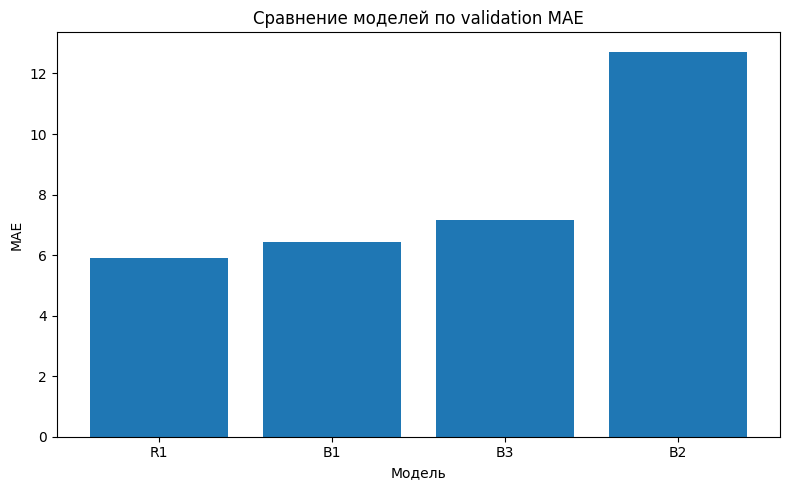

In [35]:
plt.figure(figsize=(8, 5))
plt.bar(val_results["experiment_id"], val_results["mae"])
plt.title("Сравнение моделей по validation MAE")
plt.xlabel("Модель")
plt.ylabel("MAE")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baselines_compare.png", dpi=150)
plt.show()

In [36]:
best_experiment_id = val_results.iloc[0]["experiment_id"]
print("Лучшая модель по validation MAE:", best_experiment_id)

Лучшая модель по validation MAE: R1


## Финальная оценка лучшего подхода на test

In [37]:
test_metrics_final = None
test_pred_final = None
test_true_final = None
best_model_name = best_experiment_id

if best_experiment_id == "B1":
    test_pred_final = test_model["lag_1"].values
    test_true_final = y_test.values
    test_metrics_final = calc_metrics(test_true_final, test_pred_final)

elif best_experiment_id == "B2":
    test_pred_final = test_model["rolling_mean_7"].values
    test_true_final = y_test.values
    test_metrics_final = calc_metrics(test_true_final, test_pred_final)

elif best_experiment_id == "B3":
    test_pred_final = ridge.predict(X_test_scaled)
    test_true_final = y_test.values
    test_metrics_final = calc_metrics(test_true_final, test_pred_final)

elif best_experiment_id == "R1":
    test_loss_r1, test_preds_r1, test_targets_r1 = evaluate_model(best_gru, test_loader, criterion)
    test_pred_final = target_scaler.inverse_transform(test_preds_r1.reshape(-1, 1)).flatten()
    test_true_final = target_scaler.inverse_transform(test_targets_r1.reshape(-1, 1)).flatten()
    test_metrics_final = calc_metrics(test_true_final, test_pred_final)

print("Test metrics for best model:")
print(test_metrics_final)

Test metrics for best model:
{'mae': 6.889397144317627, 'rmse': np.float64(8.67680831662637), 'mape': np.float32(4.4421067), 'smape': np.float32(4.508239)}


## Визуализация прогноза и кривых обучения

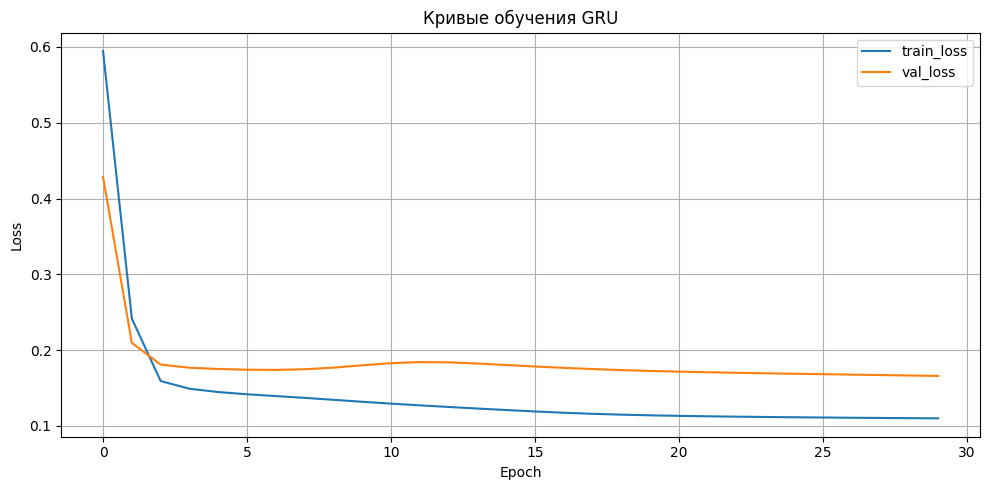

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Кривые обучения GRU")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gru_learning_curves.png", dpi=150)
plt.show()

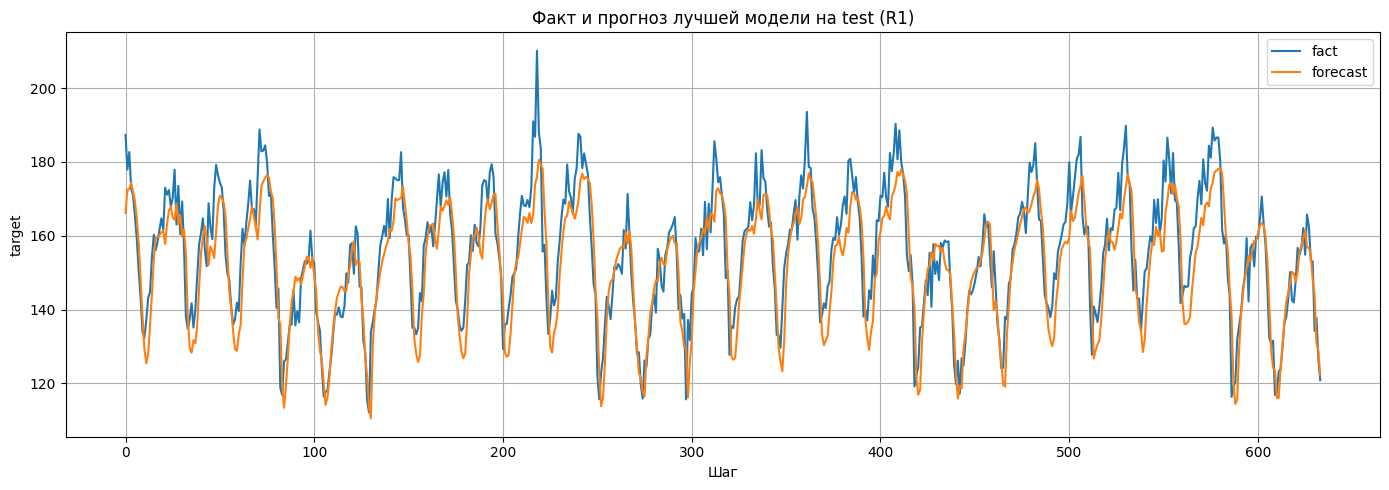

In [39]:
plt.figure(figsize=(14, 5))
plt.plot(test_true_final, label="fact")
plt.plot(test_pred_final, label="forecast")
plt.title(f"Факт и прогноз лучшей модели на test ({best_model_name})")
plt.xlabel("Шаг")
plt.ylabel("target")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "best_forecast_test.png", dpi=150)
plt.show()

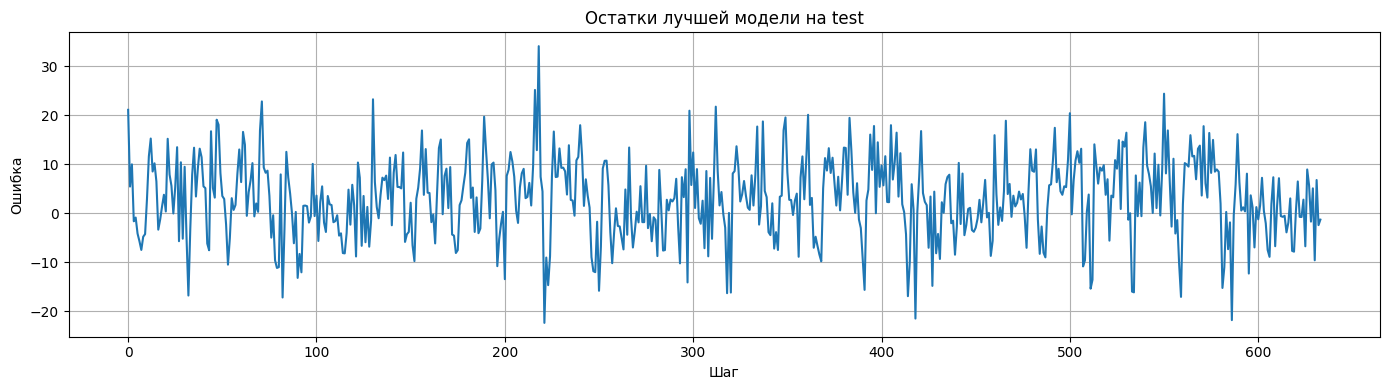

In [40]:
residuals = np.array(test_true_final) - np.array(test_pred_final)

plt.figure(figsize=(14, 4))
plt.plot(residuals)
plt.title("Остатки лучшей модели на test")
plt.xlabel("Шаг")
plt.ylabel("Ошибка")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "residuals_best.png", dpi=150)
plt.show()

## Сохранение результатов и артефактов

In [41]:
runs = []

runs.append({
    "experiment_id": "B1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": "70/15/15 temporal split",
    "window_size": None,
    "horizon": 1,
    "model_summary": "naive-last",
    "features_summary": "last value",
    "scaler": None,
    "optimizer": None,
    "lr": None,
    "epochs_trained": 0,
    "best_val_mae": metrics_b1_val["mae"],
    "best_val_rmse": metrics_b1_val["rmse"],
    "best_val_mape": metrics_b1_val["mape"],
    "test_mae": test_metrics_final["mae"] if best_experiment_id == "B1" else None,
    "test_rmse": test_metrics_final["rmse"] if best_experiment_id == "B1" else None,
    "test_mape": test_metrics_final["mape"] if best_experiment_id == "B1" else None,
    "notes": "Baseline naive last observation"
})

runs.append({
    "experiment_id": "B2",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": "70/15/15 temporal split",
    "window_size": 7,
    "horizon": 1,
    "model_summary": "moving-average",
    "features_summary": "rolling_mean_7",
    "scaler": None,
    "optimizer": None,
    "lr": None,
    "epochs_trained": 0,
    "best_val_mae": metrics_b2_val["mae"],
    "best_val_rmse": metrics_b2_val["rmse"],
    "best_val_mape": metrics_b2_val["mape"],
    "test_mae": test_metrics_final["mae"] if best_experiment_id == "B2" else None,
    "test_rmse": test_metrics_final["rmse"] if best_experiment_id == "B2" else None,
    "test_mape": test_metrics_final["mape"] if best_experiment_id == "B2" else None,
    "notes": "Baseline moving average"
})

runs.append({
    "experiment_id": "B3",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": "70/15/15 temporal split",
    "window_size": None,
    "horizon": 1,
    "model_summary": "Ridge",
    "features_summary": "lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, day_of_week",
    "scaler": "StandardScaler(features)",
    "optimizer": None,
    "lr": None,
    "epochs_trained": 0,
    "best_val_mae": metrics_b3_val["mae"],
    "best_val_rmse": metrics_b3_val["rmse"],
    "best_val_mape": metrics_b3_val["mape"],
    "test_mae": test_metrics_final["mae"] if best_experiment_id == "B3" else None,
    "test_rmse": test_metrics_final["rmse"] if best_experiment_id == "B3" else None,
    "test_mape": test_metrics_final["mape"] if best_experiment_id == "B3" else None,
    "notes": "Ridge on lag, rolling and calendar features"
})

runs.append({
    "experiment_id": "R1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": "70/15/15 temporal split",
    "window_size": window_size,
    "horizon": horizon,
    "model_summary": f"GRU hidden_size={hidden_size}, num_layers={num_layers}",
    "features_summary": "target windows only",
    "scaler": "StandardScaler(target_only)",
    "optimizer": "Adam",
    "lr": lr,
    "epochs_trained": epochs,
    "best_val_mae": metrics_r1_val["mae"],
    "best_val_rmse": metrics_r1_val["rmse"],
    "best_val_mape": metrics_r1_val["mape"],
    "test_mae": test_metrics_final["mae"] if best_experiment_id == "R1" else None,
    "test_rmse": test_metrics_final["rmse"] if best_experiment_id == "R1" else None,
    "test_mape": test_metrics_final["mape"] if best_experiment_id == "R1" else None,
    "notes": "GRU forecasting with window representation"
})

runs_df = pd.DataFrame(runs)
runs_df.to_csv(RUNS_PATH, index=False)
runs_df

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,70/15/15 temporal split,NaN,1,naive-last,last value,None,None,NaN,0,6.443406,8.203532,4.394594,NaN,NaN,NaN,Baseline naive last observation
1,B2,forecasting,S12-hw-dataset.csv,42,70/15/15 temporal split,7.0,1,moving-average,rolling_mean_7,None,None,NaN,0,12.723717,15.236326,8.828779,NaN,NaN,NaN,Baseline moving average
2,B3,forecasting,S12-hw-dataset.csv,42,70/15/15 temporal split,NaN,1,Ridge,"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler(features),None,NaN,0,7.171741,8.723752,4.782421,NaN,NaN,NaN,"Ridge on lag, rolling and calendar features"
3,R1,forecasting,S12-hw-dataset.csv,42,70/15/15 temporal split,14.0,1,"GRU hidden_size=32, num_layers=1",target windows only,StandardScaler(target_only),Adam,0.001,30,5.891451,7.532258,3.962962,6.889397,8.676808,4.442107,GRU forecasting with window representation
